In [96]:
# Indian startup funding cleanup
# Download the Kaggle Indian startup funding dataset. The amounts are strings like "1,50,00,000" and cities are spelled five ways.
# Clean both with str.replace, pd.to_numeric(errors="coerce") and a mapping dict; then plot total funding by year and top 10 cities.
# This is exactly the messiness of real work.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [98]:
df = pd.read_csv("startup_funding.csv")

In [99]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [100]:
df.tail()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"
3043,3044,31/01/2015,couponmachine.in,NaN,NaN,NaN,UK based Group of Angel Investors,Seed Funding,"1,40,000",NaN


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [102]:
df.describe()

,Sr No
count,3044.000000
mean,1522.500000
std,878.871435
min,1.000000
25%,761.750000
50%,1522.500000
75%,2283.250000
max,3044.000000


In [103]:
df.isnull()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
3039,False,False,False,True,True,True,False,False,False,True
3040,False,False,False,True,True,True,False,False,False,False
3041,False,False,False,True,True,True,False,False,False,True
3042,False,False,False,True,True,True,False,False,True,False


In [104]:
df.isnull().sum()

Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64

In [105]:
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')

In [106]:
df.dtypes

Sr No                 int64
Date dd/mm/yyyy      object
Startup Name         object
Industry Vertical    object
SubVertical          object
City  Location       object
Investors Name       object
InvestmentnType      object
Amount in USD        object
Remarks              object
dtype: object

In [107]:
df.shape

(3044, 10)

In [108]:
df.drop(columns = ['Sr No','Remarks'],inplace = True)

In [109]:
# dropping unnecesay colums
df.columns

Index(['Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical',
       'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD'],
      dtype='object')

In [110]:
#rename_columns
df.rename(columns = {
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup_name',
    'Industry Vertical':'industry_vertical',
    'SubVertical':'SubVertical',
    'City  Location':'location',
    'Investors Name':'Investor_Name',
    'InvestmentnType':'Investment_Type',
    'Amount in USD':'amount',
    'InvestmentnType':'investment round'
},inplace = True)

In [111]:
df.columns

Index(['date', 'startup_name', 'industry_vertical', 'SubVertical', 'location',
       'Investor_Name', 'investment round', 'amount'],
      dtype='object')

In [112]:
df.isnull().sum() # check null values

date                   0
startup_name           0
industry_vertical    171
SubVertical          936
location             180
Investor_Name         24
investment round       4
amount               960
dtype: int64

In [113]:
df.duplicated().sum()

0

In [114]:
# remove commas
df['amount'] = df['amount'].str.replace(",","",regex=False)

In [115]:
#convert the data types
df['amount']  = pd.to_numeric(df['amount'],errors='coerce') # amount col is also int type and clean

In [116]:
df.dtypes

date                  object
startup_name          object
industry_vertical     object
SubVertical           object
location              object
Investor_Name         object
investment round      object
amount               float64
dtype: object

In [117]:
df.head()

,date,startup_name,industry_vertical,SubVertical,location,Investor_Name,investment round,amount
0,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
1,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
2,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
4,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0


In [118]:
df['location'] # location col is clean

0       Bengaluru
1         Gurgaon
2       Bengaluru
3       New Delhi
4          Mumbai
          ...    
3039          NaN
3040          NaN
3041          NaN
3042          NaN
3043          NaN
Name: location, Length: 3044, dtype: object

In [119]:
print(df["location"].value_counts())

location
Bangalore             700
Mumbai                567
New Delhi             421
Gurgaon               287
Bengaluru             141
                     ... 
Delhi & Cambridge       1
Bhubneswar              1
Srinagar                1
Rourkela                1
Dallas / Hyderabad      1
Name: count, Length: 112, dtype: int64


In [120]:
df.head()

,date,startup_name,industry_vertical,SubVertical,location,Investor_Name,investment round,amount
0,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
1,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
2,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
4,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0


In [147]:
# top 10 city by funcding 
top_10_city_by_funding = (df.groupby('location')['amount'].sum().sort_values(ascending=False).head(10))

In [149]:
top_10_city_by_funding

location
Bangalore     1.136159e+10
Bengaluru     7.098579e+09
Mumbai        4.921185e+09
New Delhi     3.017817e+09
Gurgaon       3.005296e+09
Noida         1.262864e+09
Gurugram      8.659325e+08
Chennai       7.187670e+08
Pune          6.330820e+08
Menlo Park    4.500000e+08
Name: amount, dtype: float64

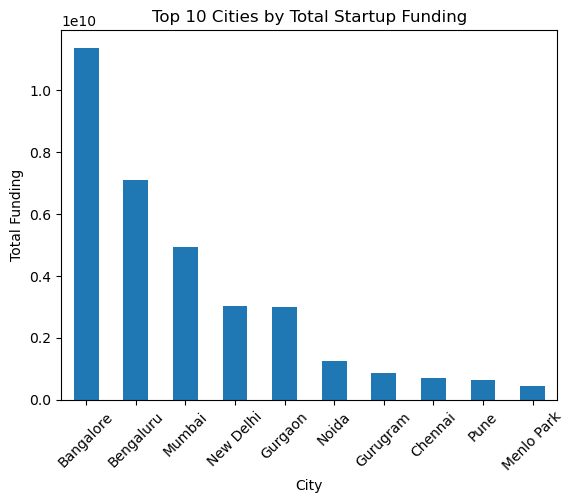

In [153]:
# plot the graph
top_10_city_by_funding.plot(kind="bar")

plt.title("Top 10 Cities by Total Startup Funding")
plt.xlabel("City")
plt.ylabel("Total Funding")
plt.xticks(rotation=45)
plt.show()